# T02 - Análisis de Sensibilidad

---
Nombre: **Alan Jesús Hernández Soto** \
Carrera: **Ingeniería Financiera** \
Materia: **Simulación de Procesos Financieros** \
Tipo de Trabajo: **Tarea**

---

## 1. Simulación de Puts y Calls

Se simula el precio final de la acción con Movimiento Browniano Geométrico y se descuenta el pago esperado de cada opción. También se calcula el precio teórico con Black-Scholes.

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

Parametros

In [40]:
S0 = 100
K = 100
r = 0.05
sigma = 0.20
T = 1
M = 10000

In [41]:
def s(r, sigma, T, S0):
    return S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * np.random.normal(0, 1))

def precio_montecarlo(S0, K, r, sigma, T, M):
    np.random.seed(1234)
    precios_finales = []
    for i in range(M):
        precios_finales.append(s(r, sigma, T, S0))
    
    precios_finales = np.array(precios_finales)
    payoff_call = np.maximum(precios_finales - K, 0)
    payoff_put = np.maximum(K - precios_finales, 0)
    
    call = np.exp(-r * T) * np.mean(payoff_call)
    put = np.exp(-r * T) * np.mean(payoff_put)
    return call, put

In [42]:
call, put = precio_montecarlo(S0, K, r, sigma, T, M)

d1 = (np.log(S0 / K) + (r + (sigma**2) / 2) * T) / (sigma * np.sqrt(T))
d2 = d1 - sigma * np.sqrt(T)
call_price = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
put_price = K * np.exp(-r * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)

comparacion = pd.DataFrame({
    'Opción': ['Call', 'Put'],
    'Monte Carlo': [call, put],
    'Black-Scholes': [call_price, put_price],
    'Diferencia': [abs(call - call_price), abs(put - put_price)]
})

display(comparacion)

,Opción,Monte Carlo,Black-Scholes,Diferencia
0,Call,10.607481,10.450584,0.156897
1,Put,5.433101,5.573526,0.140425


La diferencia entre Monte Carlo y Black-Scholes es muy minima

## 2. Sensibilidad

Se cambia un parámetro a la vez y los demás se mantienen en los valores iniciales.

In [43]:
valores_S0 = [80, 90, 100, 110, 120]
calls_S0 = []
puts_S0 = []
for valor in valores_S0:
    call, put = precio_montecarlo(valor, K, r, sigma, T, M)
    calls_S0.append(call)
    puts_S0.append(put)
s_S0 = pd.DataFrame({'S0': valores_S0, 'Call': calls_S0, 'Put': puts_S0})

valores_K = [80, 90, 100, 110, 120]
calls_K = []
puts_K = []
for valor in valores_K:
    call, put = precio_montecarlo(S0, valor, r, sigma, T, M)
    calls_K.append(call)
    puts_K.append(put)
s_K = pd.DataFrame({'K': valores_K, 'Call': calls_K, 'Put': puts_K})

valores_sigma = [0.10, 0.20, 0.30, 0.40, 0.50]
calls_sigma = []
puts_sigma = []
for valor in valores_sigma:
    call, put = precio_montecarlo(S0, K, r, valor, T, M)
    calls_sigma.append(call)
    puts_sigma.append(put)
s_sigma = pd.DataFrame({'sigma': valores_sigma, 'Call': calls_sigma, 'Put': puts_sigma})

valores_T = [0.25, 0.5, 1, 1.5, 2]
calls_T = []
puts_T = []
for valor in valores_T:
    call, put = precio_montecarlo(S0, K, r, sigma, valor, M)
    calls_T.append(call)
    puts_T.append(put)
s_T = pd.DataFrame({'T': valores_T, 'Call': calls_T, 'Put': puts_T})

valores_r = [0.05, 0.10, 0.15, 0.20]
calls_r = []
puts_r = []
for valor in valores_r:
    call, put = precio_montecarlo(S0, K, valor, sigma, T, M)
    calls_r.append(call)
    puts_r.append(put)
s_r = pd.DataFrame({'r': valores_r, 'Call': calls_r, 'Put': puts_r})

In [44]:
display(s_S0)
display(s_K)
display(s_sigma)
display(s_T)
display(s_r)

,S0,Call,Put
0,80,1.875370,16.760454
1,90,5.161640,10.016992
2,100,10.607481,5.433101
3,110,17.910296,2.706184
4,120,26.497715,1.263871


,K,Call,Put
0,80,24.876495,0.677526
1,90,16.931470,2.244796
2,100,10.607481,5.433101
3,110,6.125111,10.463025
4,120,3.284109,17.134317


,sigma,Call,Put
0,0.1,6.906038,1.873174
1,0.2,10.607481,5.433101
2,0.3,14.431038,9.135141
3,0.4,18.248452,12.857727
4,0.5,22.018433,16.567375


,T,Call,Put
0,0.25,4.688422,3.290395
1,0.50,6.995893,4.310420
2,1.00,10.607481,5.433101
3,1.50,13.639076,6.058632
4,2.00,16.356655,6.440709


,r,Call,Put
0,0.05,10.607481,5.433101
1,0.10,13.462375,3.648795
2,0.15,16.584205,2.357680
3,0.20,19.885301,1.461054


## 3. Visualización

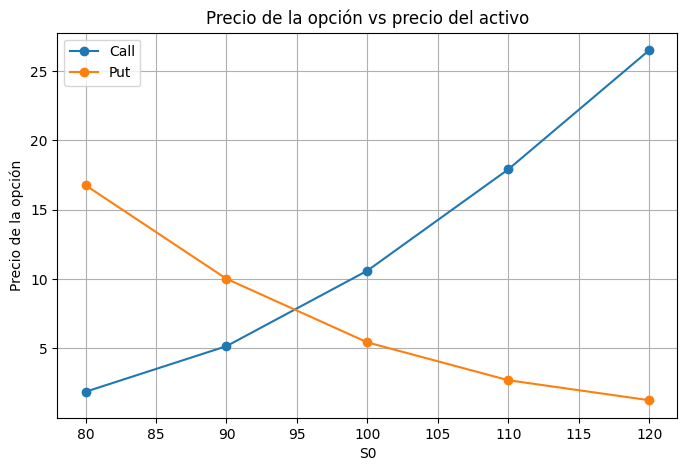

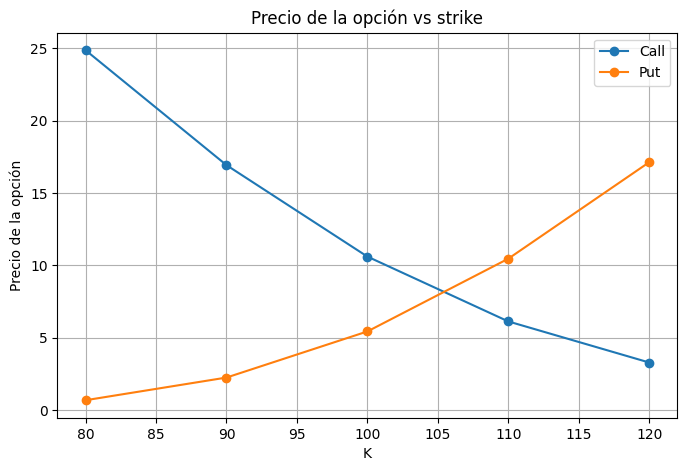

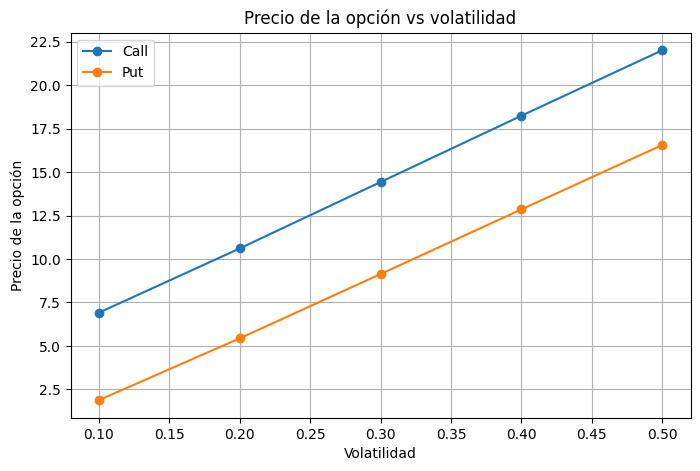

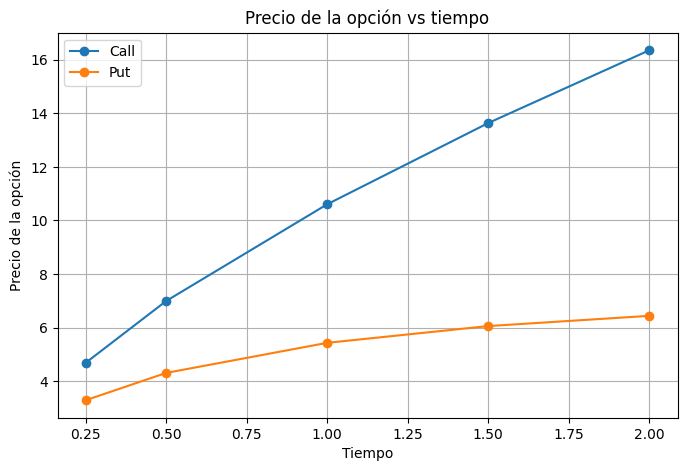

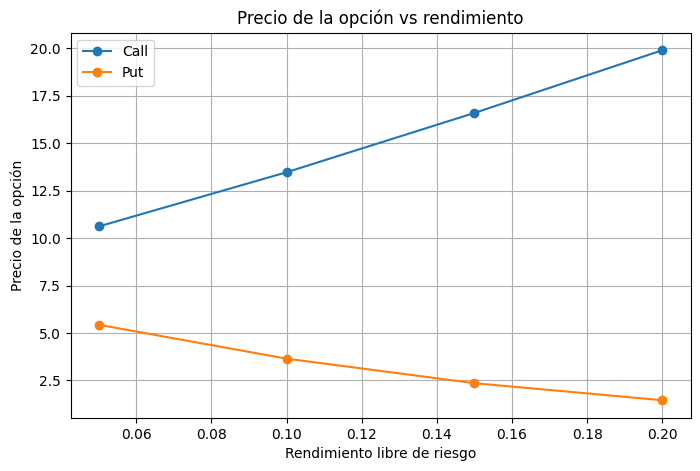

In [45]:
def gs(datos, columna, titulo, etiqueta_x):
    plt.figure(figsize=(8, 5))
    plt.plot(datos[columna], datos['Call'], marker='o', label='Call')
    plt.plot(datos[columna], datos['Put'], marker='o', label='Put')
    plt.title(titulo)
    plt.xlabel(etiqueta_x)
    plt.ylabel('Precio de la opción')
    plt.grid()
    plt.legend()
    plt.show()



gs(s_S0, 'S0', 'Precio de la opción vs precio del activo', 'S0')
gs(s_K, 'K', 'Precio de la opción vs strike', 'K')
gs(s_sigma, 'sigma', 'Precio de la opción vs volatilidad', 'Volatilidad')
gs(s_T, 'T', 'Precio de la opción vs tiempo', 'Tiempo')
gs(s_r, 'r', 'Precio de la opción vs rendimiento', 'Rendimiento libre de riesgo')

## 4. Interpretación

### Precio del activo
- Una **call** aumenta de valor cuando aumenta el precio de la acción porque da derecho a comprar a un strike fijo. Si la acción vale más que el strike, se puede comprar barato y el pago potencial crece.
- Una **put** se comporta de forma contraria: da derecho a vender a un strike fijo. Cuando el precio del activo sube, es menos útil vender a ese precio fijo; por eso su valor disminuye.

### Volatilidad
- Una mayor volatilidad aumenta el valor de calls y puts. Hay mayor posibilidad de terminar muy arriba o muy abajo del strike, mientras que la pérdida está limitada a la prima pagada. En los resultados, al pasar de 10% a 50%, ambas opciones aumentan.

### Tiempo
- Más tiempo normalmente aumenta el valor de ambas opciones, porque existe más oportunidad de que el precio termine favorablemente.
- Para el comprador da más flexibilidad, pero también implica pagar una prima mayor y no garantiza una ganancia. Para el vendedor representa más tiempo de exposición al riesgo, aunque recibe una prima mayor.

### Strike
- Para una call, subir el strike disminuye la probabilidad de terminar *in-the-money* y reduce su valor. Para una put ocurre lo contrario.
- *In-the-money* significa que ejercer la opción al vencimiento genera un valor positivo: para una call, $S_T > K$; para una put, $S_T < K$.

## 5. Comparación con el mercado

Como inversionista, el parámetro más importante a monitorear sería la **volatilidad**. No se observa directamente y puede cambiar mucho cuando hay noticias, resultados financieros o incertidumbre económica. En esta simulación, al aumentar la volatilidad de 10% a 50%, tanto la call como la put suben de manera importante. Por lo tanto, un cambio en volatilidad puede modificar el valor de la opción incluso si el precio no cambia.